### __Importamos datos de alpaca__

In [1]:
from alpaca.data.historical import StockHistoricalDataClient
from alpaca.data.requests import StockBarsRequest
from alpaca.data.timeframe import TimeFrame

import pandas as pd
from datetime import datetime

#Gestionamos API
API_KEY = "PKCB2FGQTEQAIQXV5CXL6RJU4D" 
SECRET_KEY = "8gsG7rUpBvUaxAzw7HPw6EEypH42UpkR4VRYHaNJoYYU"

client = StockHistoricalDataClient(API_KEY, SECRET_KEY)

# Definimos los datos que queremos descargar, su fecha de inicio y su fecha de fin
symbols = ["AAPL"]

start = datetime(2015,1,1)
end = datetime(2026,1,1)

# Descargamos los datos de ALPACA
request = StockBarsRequest(
    symbol_or_symbols=symbols,
    timeframe=TimeFrame.Day,
    start=start,
    end=end
)

bars = client.get_stock_bars(request)

# Convertimos las columnas a dataset
df = bars.df
df = df.reset_index()
df.head()

,symbol,timestamp,open,high,low,close,volume,trade_count,vwap
0,AAPL,2016-01-04 05:00:00+00:00,102.61,105.368,102.00,105.35,71935339.0,351452.0,104.007250
1,AAPL,2016-01-05 05:00:00+00:00,105.75,105.850,102.41,102.71,58690536.0,321365.0,103.414304
2,AAPL,2016-01-06 05:00:00+00:00,100.56,102.370,99.87,100.70,71079827.0,409164.0,100.847762
3,AAPL,2016-01-07 05:00:00+00:00,98.68,100.130,96.43,96.45,85996453.0,462836.0,98.046209
4,AAPL,2016-01-08 05:00:00+00:00,98.55,99.110,96.76,96.96,75066292.0,419555.0,97.916490


### __Ordenamos y limpiamos el dataset__

In [2]:
df = df.sort_values("timestamp")
df = df.reset_index(drop=True)

### __Creamos EMA_fast (12 días) y EMA_slow (26 días)__

In [3]:
df["EMA12"] = df["close"].ewm(span=12, adjust=False).mean()
df["EMA26"] = df["close"].ewm(span=26, adjust=False).mean()

### __Creamos MACD y signal__

In [4]:
df["MACD"] = df["EMA12"] - df["EMA26"]

df["Signal"] = df["MACD"].ewm(span=9, adjust=False).mean()

df["Histogram"] = df["MACD"] - df["Signal"]


### __Visualizaciones rápidas__

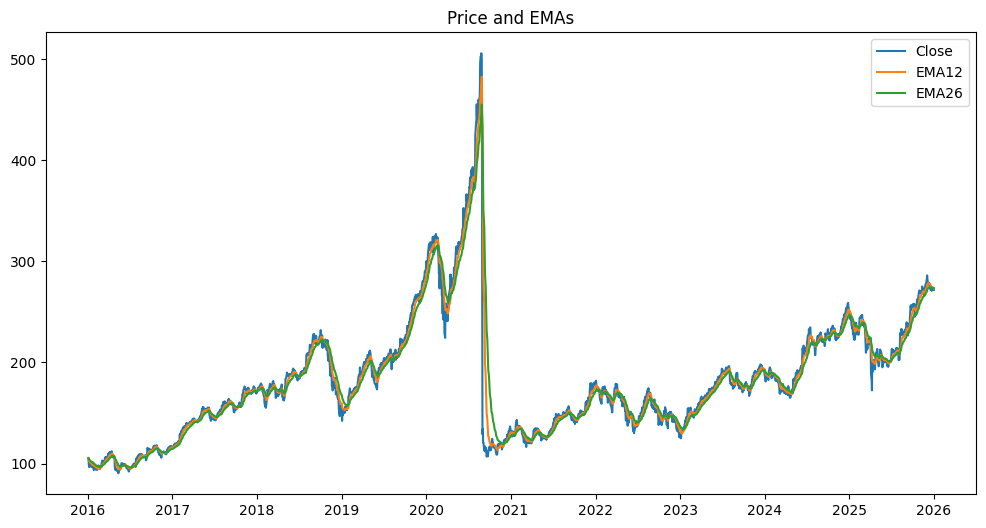

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(df["timestamp"], df["close"], label="Close")
plt.plot(df["timestamp"], df["EMA12"], label="EMA12")
plt.plot(df["timestamp"], df["EMA26"], label="EMA26")

plt.legend()
plt.title("Price and EMAs")
plt.show()

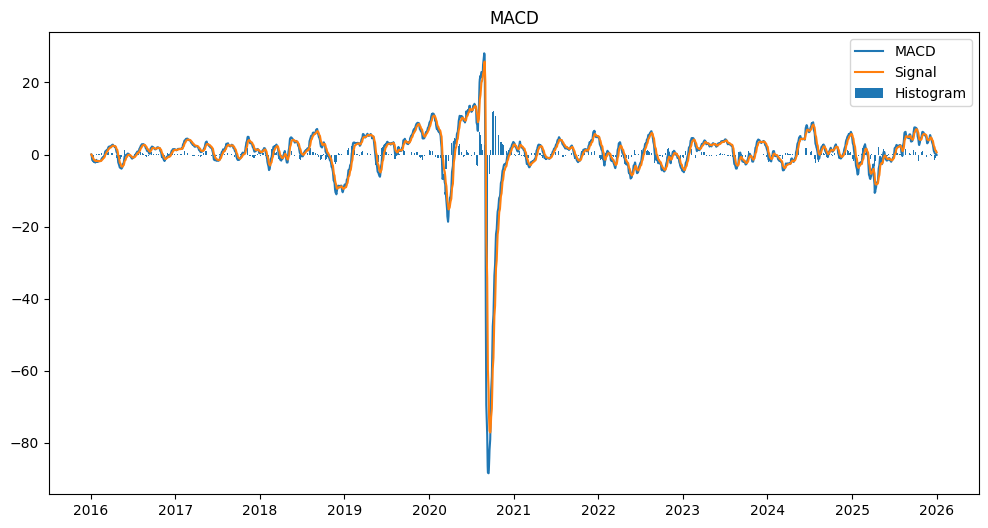

In [6]:
plt.figure(figsize=(12,6))

plt.plot(df["timestamp"], df["MACD"], label="MACD")
plt.plot(df["timestamp"], df["Signal"], label="Signal")

plt.bar(df["timestamp"], df["Histogram"], label="Histogram")

plt.legend()
plt.title("MACD")
plt.show()

### __Estrategias__
Vamos a generar la estrategia de EMA's Crossover que es muy simplona y la estrategia de MACD con signal

In [7]:
# Estretagia crossover EMA's --> Si EMA_12 > EMA_26 hacemos long, en caso contrario short
df["crossover_pos"] = 0

df.loc[df["EMA12"] > df["EMA26"], "crossover_pos"] = 1
df.loc[df["EMA12"] < df["EMA26"], "crossover_pos"] = -1

In [8]:
# Estrategia MACD signal 
macd_pos = []
position = 0  # 0 = hold, 1 = long, -1 = short

for hist in df["Histogram"]:

    if position == 0:
        
        if hist < -0.4:
            position = 1
        
        elif hist > 0.4:
            position = -1

    elif position == 1:
        
        if hist > -0.1:
            position = 0

    elif position == -1:
        
        if hist < 0.1:
            position = 0

    macd_pos.append(position)
    
# Guardamos la lista generada en el dataframe    
df["macd_pos"] = macd_pos

### __Comprobación rápida de resultados__

In [9]:
df[["timestamp", "MACD", "Histogram", "crossover_pos", "macd_pos"]].tail(20)

,timestamp,MACD,Histogram,crossover_pos,macd_pos
2494,2025-12-03 05:00:00+00:00,5.403958,0.862968,1,-1
2495,2025-12-04 05:00:00+00:00,5.240662,0.559737,1,-1
2496,2025-12-05 05:00:00+00:00,4.899839,0.175131,1,-1
2497,2025-12-08 05:00:00+00:00,4.505976,-0.174986,1,0
2498,2025-12-09 05:00:00+00:00,4.089405,-0.473245,1,1
2499,2025-12-10 05:00:00+00:00,3.844065,-0.574868,1,1
2500,2025-12-11 05:00:00+00:00,3.548211,-0.696578,1,1
2501,2025-12-12 05:00:00+00:00,3.295924,-0.759092,1,1
2502,2025-12-15 05:00:00+00:00,2.728053,-1.061570,1,1
2503,2025-12-16 05:00:00+00:00,2.291937,-1.198149,1,1


### __Guardamos el dataset que hemos generado en un CSV__

In [10]:
df.to_csv("dataset_trading_lstm.csv", index=False)

### __Preparación final de los modelos__

In [11]:
df["ema_diff"] = df["MACD"]
df["ema_diff"] = (df["ema_diff"] - df["ema_diff"].mean()) / df["ema_diff"].std()

In [12]:
import numpy as np

# Funcion para crear las secuencias de datos con las que se entrenará la LSTM
def create_sequences(data, target, lookback):
    
    X = []
    y = []
    
    for i in range(len(data) - lookback):
        
        X.append(data[i:i+lookback])
        y.append(target[i+lookback])
        
    return np.array(X), np.array(y)

#### __Creamos dataset final de Crossover__

In [13]:
lookback = 5 #se puede ir jugando con este valor

X_cross, y_cross = create_sequences(
    df["ema_diff"].values,
    df["crossover_pos"].values,
    lookback
)

# Ajustamos dimensiones para LSTM, ya que esperan los datos como (filas, time_steps, features)

X_cross = X_cross.reshape(X_cross.shape[0], lookback, 1)

#### __Creamos dataset final de MACD__

In [14]:
X_macd, y_macd = create_sequences(
    df["Histogram"].values,
    df["macd_pos"].values,
    lookback
)

X_macd = X_macd.reshape(X_macd.shape[0], lookback, 1)

### __Dividimos el conjunto de entrenamiento y test para ambos conjuntos de datos__

La division será del 80% de datos de train y 20% de datos para testing

In [35]:
# Division para los datos de Crossover
split = int(len(X_cross)*0.8)

X_cross_train = X_cross[:split]
X_cross_test = X_cross[split:]

y_cross_train = y_cross[:split]
y_cross_test = y_cross[split:]

# Division para los datos de MACD
split = int(len(X_macd)*0.8)

X_macd_train = X_macd[:split]
X_macd_test = X_macd[split:]

y_macd_train = y_macd[:split]
y_macd_test = y_macd[split:]

# Comprobamos dimensiones --> deberia salir (numero samples, 5, 1)
print("Crossover dataset")
print(X_cross_train.shape, y_cross_train.shape)
print(X_cross_test.shape, y_cross_test.shape)

print("MACD dataset")
print(X_macd_train.shape, y_macd_train.shape)
print(X_macd_test.shape, y_macd_test.shape)

Crossover dataset
(2007, 5, 1) (2007,)
(502, 5, 1) (502,)
MACD dataset
(2007, 5, 1) (2007,)
(502, 5, 1) (502,)


### __Generación de LSTM's__
Se generarán dos LSTM's, una que solo recibe 1 única unidad (input_size=1) y otra que reciba 15 unidades (input_size=15), para comparar los resultados

In [36]:
import torch
import torch.nn as nn

class LSTMModel(nn.Module):

    def __init__(self):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=1,
            hidden_size=1,
            batch_first=True
        )

        self.tanh = nn.Tanh()

    def forward(self, x):

        out, _ = self.lstm(x)

        out = out[:, -1, :]

        out = self.tanh(out)

        return out
    
    def forward_with_states(self, x):

        out, (h_n, c_n) = self.lstm(x)
        out_last = out[:, -1, :]
        out_last = self.tanh(out_last)

        return out_last, h_n, c_n

#### __Convertimos los datasets a tensores__

In [37]:
X_cross_train = torch.tensor(X_cross_train, dtype=torch.float32)
y_cross_train = torch.tensor(y_cross_train, dtype=torch.float32).unsqueeze(1)

X_cross_test = torch.tensor(X_cross_test, dtype=torch.float32)
y_cross_test = torch.tensor(y_cross_test, dtype=torch.float32).unsqueeze(1)

X_macd_train = torch.tensor(X_macd_train, dtype=torch.float32)
y_macd_train = torch.tensor(y_macd_train, dtype=torch.float32).unsqueeze(1)

X_macd_test = torch.tensor(X_macd_test, dtype=torch.float32)
y_macd_test = torch.tensor(y_macd_test, dtype=torch.float32).unsqueeze(1)

#### __Creamos los bacthes de entrenamiento__

In [38]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset_cross = TensorDataset(X_cross_train, y_cross_train)
train_dataset_macd = TensorDataset(X_macd_train, y_macd_train)

train_loader_cross = DataLoader(
    train_dataset_cross,
    batch_size=32,
    shuffle=True
)

train_loader_macd = DataLoader(
    train_dataset_macd,
    batch_size=32,
    shuffle=True
)

#### __Loss y Optimizer__

In [39]:
model_cross = LSTMModel()
model_macd = LSTMModel()

criterion = nn.MSELoss()

optimizer_cross = torch.optim.RMSprop(model_cross.parameters(), lr=0.001)
optimizer_macd = torch.optim.RMSprop(model_macd.parameters(), lr=0.001)

#### __Training Loop__

In [40]:
epochs = 200

for epoch in range(epochs):

    epoch_loss = 0

    for X_batch, y_batch in train_loader_cross:

        optimizer_cross.zero_grad()

        outputs = model_cross(X_batch)

        loss = criterion(outputs, y_batch)

        loss.backward()

        optimizer_cross.step()

        epoch_loss += loss.item()

    if epoch % 20 == 0:
        print("Epoch:", epoch, "Loss:", epoch_loss)

Epoch: 0 Loss: 52.61620384454727
Epoch: 20 Loss: 19.303705543279648
Epoch: 40 Loss: 14.55172760784626
Epoch: 60 Loss: 12.813421800732613
Epoch: 80 Loss: 11.93089172244072
Epoch: 100 Loss: 11.311891168355942
Epoch: 120 Loss: 10.874432183802128
Epoch: 140 Loss: 10.494665674865246
Epoch: 160 Loss: 10.206708706915379
Epoch: 180 Loss: 9.987942196428776


In [41]:
epochs = 500

for epoch in range(epochs):

    for X_batch, y_batch in train_loader_macd:

        optimizer_macd.zero_grad()

        outputs = model_macd(X_batch)

        loss = criterion(outputs, y_batch)

        loss.backward()

        optimizer_macd.step()

    if epoch % 50 == 0:
        print("epoch", epoch, "loss", loss.item())

epoch 0 loss 1.0272923707962036
epoch 50 loss 0.3850173056125641
epoch 100 loss 0.11896385252475739
epoch 150 loss 0.08093751221895218
epoch 200 loss 0.14252005517482758
epoch 250 loss 0.11752764880657196
epoch 300 loss 0.09152527153491974
epoch 350 loss 0.11147881299257278
epoch 400 loss 0.10018894076347351
epoch 450 loss 0.09043466299772263


#### __Evaluacion__

In [42]:
with torch.no_grad():
    
    preds = model_cross(X_cross_test)
    
    preds = torch.sign(preds)
    
accuracy = (preds == y_cross_test).float().mean()

print("Accuracy:", accuracy.item())

Accuracy: 0.9601593613624573


In [43]:
with torch.no_grad():
    preds = model_macd(X_macd_test)

preds = torch.sign(preds)

accuracy = (preds == y_macd_test).float().mean()

print("MACD accuracy:", accuracy.item())

MACD accuracy: 0.7788844704627991


### __Visualización de predicciones de la red__

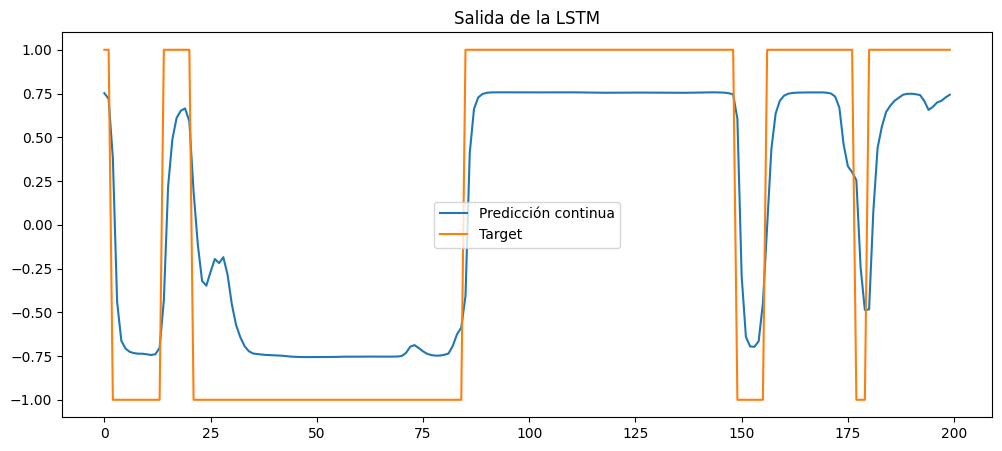

In [44]:
with torch.no_grad():
    preds = model_cross(X_cross_test)

preds = preds.numpy()
targets = y_cross_test.numpy()

# Visualizamos predicciones

plt.figure(figsize=(12,5))

plt.plot(preds[:200], label="Predicción continua")
plt.plot(targets[:200], label="Target")

plt.legend()
plt.title("Salida de la LSTM")
plt.show()

### __Visualización memoria interna de la red__

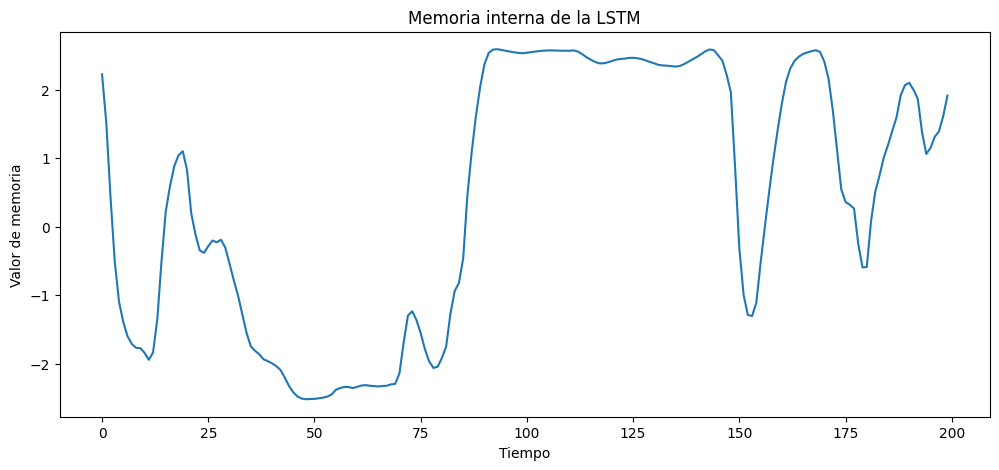

In [45]:
with torch.no_grad():

    preds, h, c = model_cross.forward_with_states(X_cross_test)

memory = c.squeeze().numpy()

plt.figure(figsize=(12,5))

plt.plot(memory[:200])

plt.title("Memoria interna de la LSTM")
plt.xlabel("Tiempo")
plt.ylabel("Valor de memoria")

plt.show()

### __Visualización de función que ha aprendido la red__

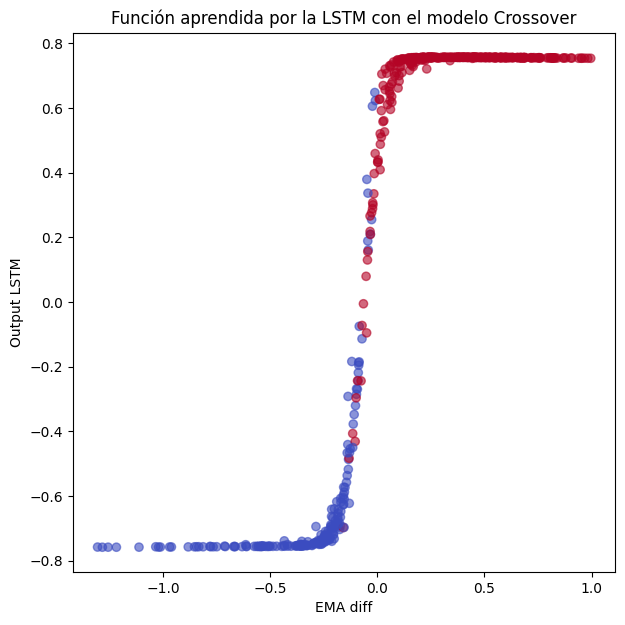

In [46]:
inputs = X_cross_test[:, -1, 0].numpy()

outputs = preds.squeeze().numpy()

targets = y_cross_test.squeeze().numpy()

plt.figure(figsize=(7,7))

plt.scatter(inputs[:500], outputs[:500], c=targets[:500], cmap="coolwarm", alpha=0.6)

plt.xlabel("EMA diff")
plt.ylabel("Output LSTM")

plt.title("Función aprendida por la LSTM con el modelo Crossover")

plt.show()

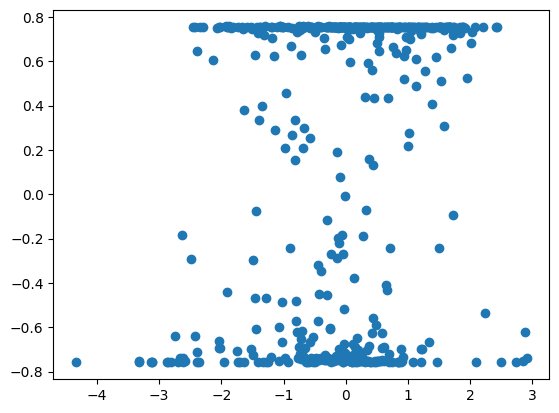

In [47]:
inputs = X_macd_test[:, -1, 0].numpy()
outputs = preds.squeeze().numpy()

plt.scatter(inputs[:500], outputs[:500])

### __Generación de predicciones sobre rentabilidad en el modelo Crossover__

In [48]:
with torch.no_grad():
    preds = model_cross(X_cross_test)

preds = torch.sign(preds).squeeze().numpy()

prices = df["close"].values
prices_test = prices[-len(preds):]

#### __Calculamos retornos__

In [49]:
returns = np.diff(prices_test) / prices_test[:-1]

strategy_returns = preds[:-1] * returns

#### __Calculamos curva de equity__

In [50]:
equity = np.cumprod(1 + strategy_returns)

market_equity = np.cumprod(1 + returns)

#### __Visualización de resultados__

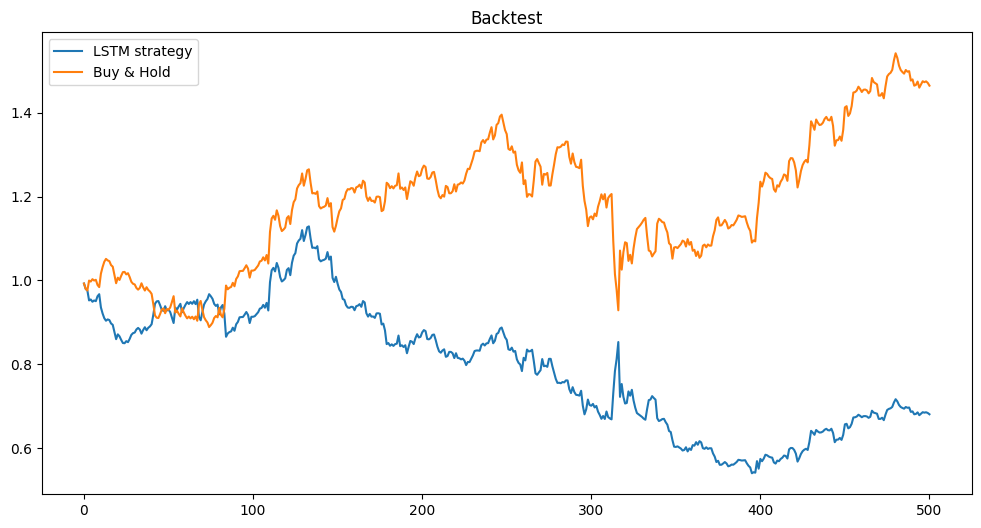

In [51]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(equity, label="LSTM strategy")
plt.plot(market_equity, label="Buy & Hold")

plt.legend()
plt.title("Backtest")

plt.show()

#### __Metricas importantes: Sharpe Ratio, Rentabilidad total, Drawdown__

In [52]:
total_return = equity[-1] - 1

sharpe = np.mean(strategy_returns) / np.std(strategy_returns) * np.sqrt(252)

cummax = np.maximum.accumulate(equity)
drawdown = (equity - cummax) / cummax

max_dd = drawdown.min()

print("Strategy return:", total_return)
print("Sharpe:", sharpe)
print("Max drawdown:", max_dd)

Strategy return: -0.31916660769967664
Sharpe: -0.5523659316775895
Max drawdown: -0.5215255138587139


### __Generación de predicciones sobre rentabilidad en el modelo MACD__

In [53]:
with torch.no_grad():
    preds = model_macd(X_macd_test)

preds = torch.sign(preds).squeeze().numpy()

prices = df["close"].values
prices_test = prices[-len(preds):]

#### __Calculamos retornos__

In [54]:
returns = np.diff(prices_test) / prices_test[:-1]

strategy_returns = preds[:-1] * returns

#### __Calculamos curva de equity__

In [55]:
equity = np.cumprod(1 + strategy_returns)

market_equity = np.cumprod(1 + returns)

#### __Visualización de estrategias__

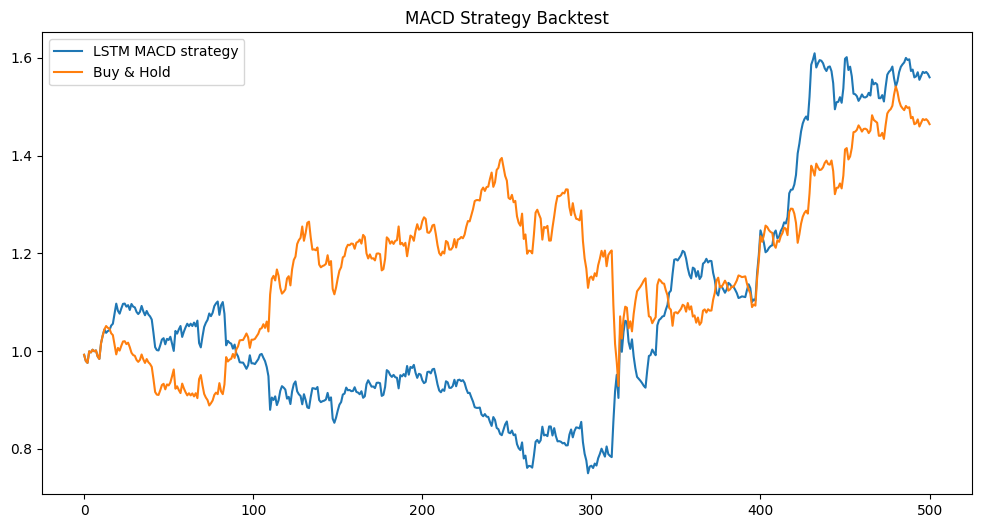

In [56]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(equity, label="LSTM MACD strategy")
plt.plot(market_equity, label="Buy & Hold")

plt.legend()
plt.title("MACD Strategy Backtest")

plt.show()

#### __Metricas importantes__

In [57]:
total_return = equity[-1] - 1

sharpe = np.mean(strategy_returns) / np.std(strategy_returns) * np.sqrt(252)

cummax = np.maximum.accumulate(equity)
drawdown = (equity - cummax) / cummax

max_dd = drawdown.min()

print("Strategy return:", total_return)
print("Sharpe:", sharpe)
print("Max drawdown:", max_dd)

Strategy return: 0.5603098494053471
Sharpe: 0.9409558708795122
Max drawdown: -0.31907959614254


## __Experimento B: Introduce más capacidad en la memoria de la LSTM__

In [58]:
class LSTMModelExpB(nn.Module):

    def __init__(self):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=1,
            hidden_size=15,
            batch_first=True
        )

        self.dropout = nn.Dropout(0.25)

        self.fc = nn.Linear(15, 1)

        self.tanh = nn.Tanh()

    def forward(self, x):

        out, _ = self.lstm(x)

        out = out[:, -1, :]

        out = self.dropout(out)

        out = self.fc(out)

        out = self.tanh(out)

        return out

In [59]:
model_expB_cross = LSTMModelExpB()
model_expB_macd = LSTMModelExpB()

criterion = nn.MSELoss()

optimizer_expB_cross = torch.optim.RMSprop(model_expB_cross.parameters(), lr=0.001)
optimizer_expB_macd = torch.optim.RMSprop(model_expB_cross.parameters(), lr=0.001)

In [60]:
epochs = 500

for epoch in range(epochs):

    epoch_loss = 0

    for X_batch, y_batch in train_loader_cross:

        optimizer_expB_cross.zero_grad()

        outputs = model_cross(X_batch)

        loss = criterion(outputs, y_batch)

        loss.backward()

        optimizer_cross.step()

        epoch_loss += loss.item()

    if epoch % 20 == 0:
        print("Epoch:", epoch, "Loss:", epoch_loss)

Epoch: 0 Loss: 9.909540623426437
Epoch: 20 Loss: 9.391911707818508
Epoch: 40 Loss: 9.121348932385445
Epoch: 60 Loss: 8.916779771447182
Epoch: 80 Loss: 8.864147804677486
Epoch: 100 Loss: 8.679130405187607
Epoch: 120 Loss: 8.506161272525787
Epoch: 140 Loss: 8.420339442789555
Epoch: 160 Loss: 8.343366034328938
Epoch: 180 Loss: 8.237024076282978
Epoch: 200 Loss: 8.212035275995731
Epoch: 220 Loss: 8.164668690413237
Epoch: 240 Loss: 8.190804816782475
Epoch: 260 Loss: 8.204709462821484
Epoch: 280 Loss: 8.218282379209995
Epoch: 300 Loss: 8.17936196923256
Epoch: 320 Loss: 8.139653250575066
Epoch: 340 Loss: 8.168432392179966
Epoch: 360 Loss: 8.147497810423374
Epoch: 380 Loss: 8.155566975474358
Epoch: 400 Loss: 8.145179696381092
Epoch: 420 Loss: 8.156068675220013
Epoch: 440 Loss: 8.119149789214134
Epoch: 460 Loss: 8.09460511058569
Epoch: 480 Loss: 8.069008499383926


In [61]:
with torch.no_grad():
    
    preds = model_expB_cross(X_cross_test)
    
    preds = torch.sign(preds)
    
accuracy = (preds == y_cross_test).float().mean()

print("Cross Accuracy:", accuracy.item())

Cross Accuracy: 0.6055777072906494
